In [1]:
# Import libraries for file handling, data processing, visualization, and model training
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Define dataset paths
original_root = Path("/kaggle/input/datasets/nsirimsamueleberechi/alzheimer-data/OriginalDataset")
augmented_root = Path("/kaggle/input/datasets/nsirimsamueleberechi/alzheimer-data/AugmentedAlzheimerDataset")

# Confirm folders exist
print("Original folders:", [p.name for p in original_root.iterdir() if p.is_dir()])
print("Augmented folders:", [p.name for p in augmented_root.iterdir() if p.is_dir()])

Original folders: ['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']
Augmented folders: ['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']


In [3]:
# Convert original 4 classes into 3 final classes
label_map = {
    "NonDemented": "Normal",
    "VeryMildDemented": "MCI",
    "MildDemented": "Alzheimer",
    "ModerateDemented": "Alzheimer"
}

In [4]:
#STEP 4 — Load image paths into dataframe
# Function to load image paths and assign labels
def build_df(root, source):
    rows = []

    for folder in root.iterdir():
        if folder.is_dir() and folder.name in label_map:
            for img in folder.glob("*"):
                if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
                    rows.append({
                        "filepath": str(img),
                        "original_label": folder.name,
                        "label": label_map[folder.name],
                        "source": source
                    })

    return pd.DataFrame(rows)

# Load original and augmented datasets
original_df = build_df(original_root, "original")
augmented_df = build_df(augmented_root, "augmented")

# Display dataset sizes
print("Original dataset size:", len(original_df))
print("Augmented dataset size:", len(augmented_df))

# Display class counts
print("\nOriginal class distribution:")
print(original_df["label"].value_counts())

print("\nAugmented class distribution:")
print(augmented_df["label"].value_counts())

Original dataset size: 6400
Augmented dataset size: 33984

Original class distribution:
label
Normal       3200
MCI          2240
Alzheimer     960
Name: count, dtype: int64

Augmented class distribution:
label
Alzheimer    15424
Normal        9600
MCI           8960
Name: count, dtype: int64


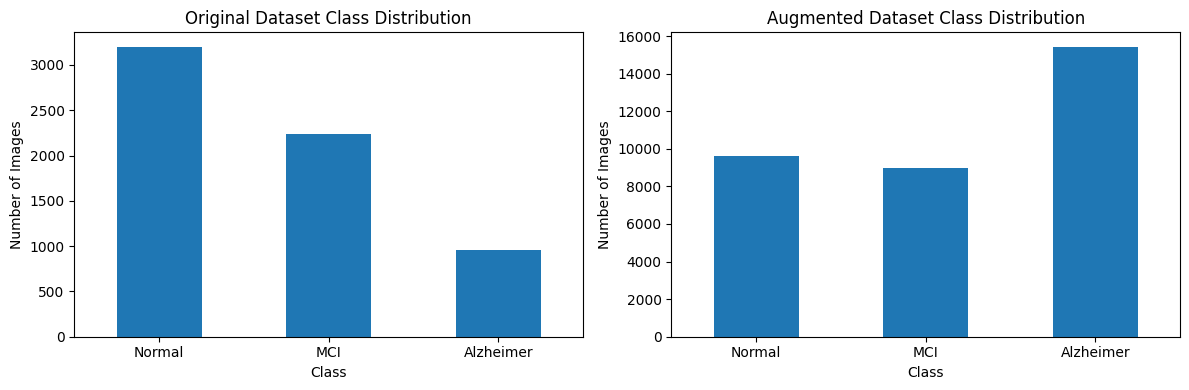

In [5]:
# Visualize original and augmented class distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

original_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[0],
    title="Original Dataset Class Distribution"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=0)

augmented_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[1],
    title="Augmented Dataset Class Distribution"
)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

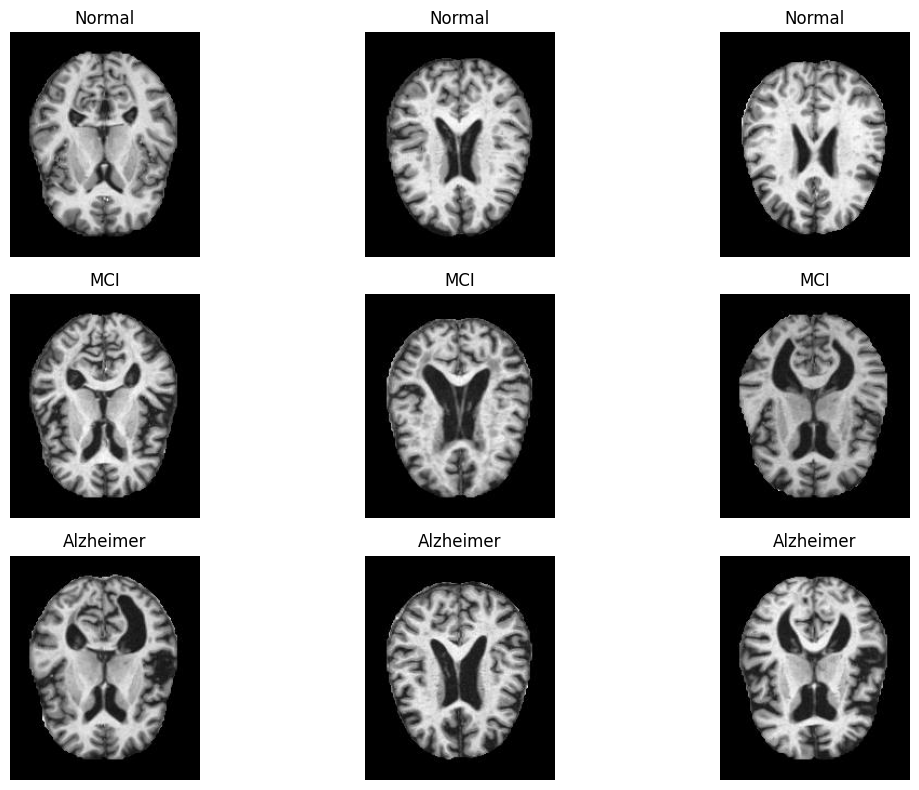

In [6]:
#Step 6
# Display sample MRI images from each final class
classes = ["Normal", "MCI", "Alzheimer"]

plt.figure(figsize=(12, 8))
plot_idx = 1

for cls in classes:
    sample_paths = original_df[original_df["label"] == cls]["filepath"].sample(
        3,
        random_state=SEED
    ).tolist()

    for path in sample_paths:
        img = Image.open(path).convert("L")
        plt.subplot(3, 3, plot_idx)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

In [7]:
# Split original dataset into train and temporary sets
train_original_df, temp_df = train_test_split(
    original_df,
    test_size=0.30,
    stratify=original_df["label"],
    random_state=SEED
)

# Split temporary set into validation and test sets
val_original_df, test_original_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

# Display split sizes
print("Original train size:", len(train_original_df))
print("Original validation size:", len(val_original_df))
print("Original test size:", len(test_original_df))

print("\nOriginal train distribution:")
print(train_original_df["label"].value_counts())

print("\nValidation distribution:")
print(val_original_df["label"].value_counts())

print("\nTest distribution:")
print(test_original_df["label"].value_counts())

Original train size: 4480
Original validation size: 960
Original test size: 960

Original train distribution:
label
Normal       2240
MCI          1568
Alzheimer     672
Name: count, dtype: int64

Validation distribution:
label
Normal       480
MCI          336
Alzheimer    144
Name: count, dtype: int64

Test distribution:
label
Normal       480
MCI          336
Alzheimer    144
Name: count, dtype: int64


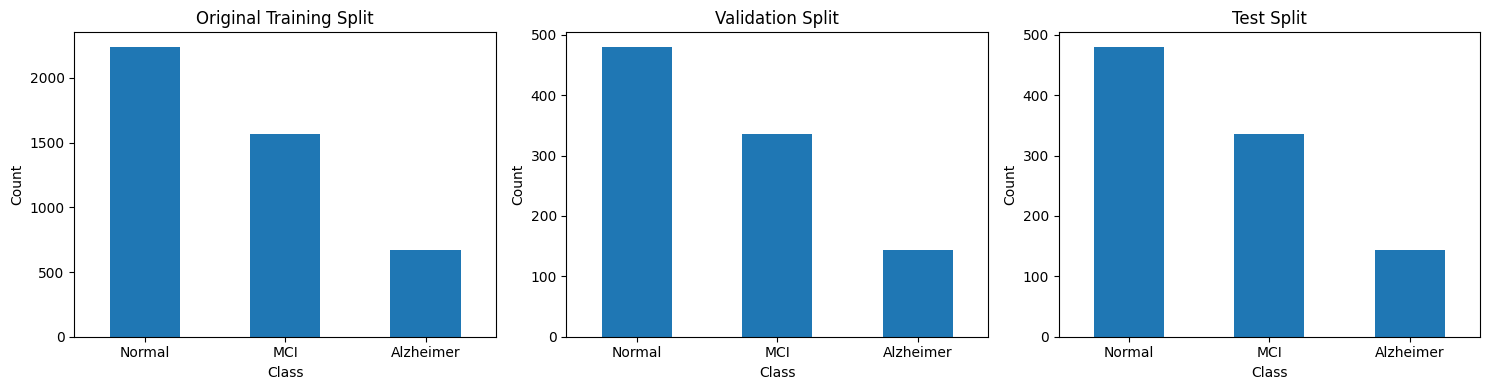

In [8]:
# Visualize class distribution across original train, validation, and test sets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_original_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[0],
    title="Original Training Split"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

val_original_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[1],
    title="Validation Split"
)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

test_original_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[2],
    title="Test Split"
)
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [9]:
#STEP 9 — Clean augmented data to reduce leakage
# STEP 9 — Proper cleaning (REPLACE your old STEP 9)

# Function to extract base image name (remove augmentation suffix)
def get_base_name(path):
    name = Path(path).stem
    name = name.split('_')[0]  # keep original image ID only
    return name

# Get base names from validation and test sets
val_test_bases = set(get_base_name(p) for p in val_original_df["filepath"]) | \
                 set(get_base_name(p) for p in test_original_df["filepath"])

# Remove augmented images linked to validation/test images
augmented_df_clean = augmented_df[
    ~augmented_df["filepath"].apply(lambda x: get_base_name(x) in val_test_bases)
].copy()

# Display result
print("Augmented before cleaning:", len(augmented_df))
print("Augmented after cleaning:", len(augmented_df_clean))

print("\nClean augmented class distribution:")
print(augmented_df_clean["label"].value_counts())

Augmented before cleaning: 33984
Augmented after cleaning: 33984

Clean augmented class distribution:
label
Alzheimer    15424
Normal        9600
MCI           8960
Name: count, dtype: int64


In [10]:
#Step 10
# Target number of training samples per class
TARGET_PER_CLASS = 4000

# Store sampled augmented images
balanced_aug = []

# Add only enough clean augmented data to reach 4000 per class
for cls in ["Normal", "MCI", "Alzheimer"]:
    current_count = len(train_original_df[train_original_df["label"] == cls])
    needed = TARGET_PER_CLASS - current_count

    if needed > 0:
        available_aug = augmented_df_clean[augmented_df_clean["label"] == cls]

        sample = available_aug.sample(
            n=min(needed, len(available_aug)),
            random_state=SEED
        )

        balanced_aug.append(sample)

# Combine selected augmented images
balanced_augmented_df = pd.concat(balanced_aug)

# Final training set = original training data + selected clean augmented data
train_final_df = pd.concat(
    [train_original_df, balanced_augmented_df],
    ignore_index=True
)

# Display final training distribution
print("Final training class distribution:")
print(train_final_df["label"].value_counts())

Final training class distribution:
label
Normal       4000
Alzheimer    4000
MCI          4000
Name: count, dtype: int64


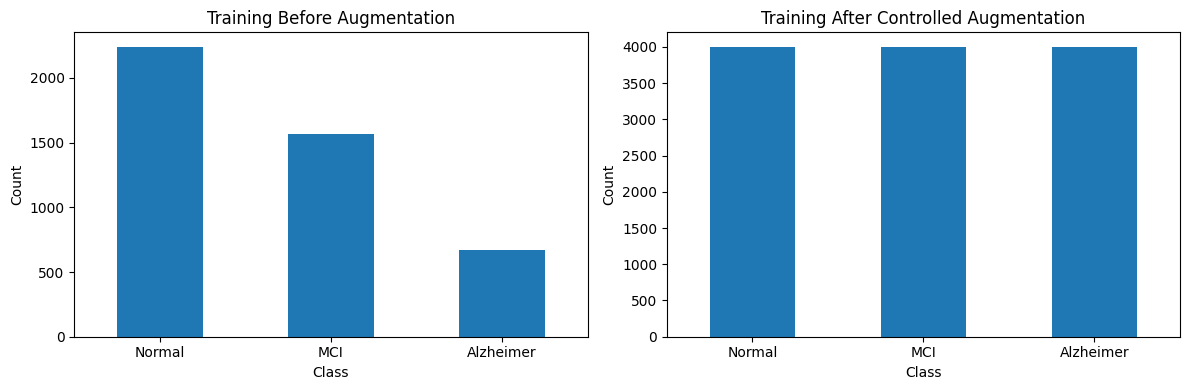

In [11]:
#Step 11
# Visualize training set before and after adding controlled augmented data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_original_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[0],
    title="Training Before Augmentation"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

train_final_df["label"].value_counts().reindex(["Normal", "MCI", "Alzheimer"]).plot(
    kind="bar",
    ax=axes[1],
    title="Training After Controlled Augmentation"
)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [12]:
#Step 12
# Compare filename stems across train, validation, and test sets
train_names = set(get_base_name(p) for p in train_final_df["filepath"])
val_names = set(get_base_name(p) for p in val_original_df["filepath"])
test_names = set(get_base_name(p) for p in test_original_df["filepath"])

print("Train-Val overlap:", len(train_names & val_names))
print("Train-Test overlap:", len(train_names & test_names))

Train-Val overlap: 120
Train-Test overlap: 110


In [13]:
# Create class-aware file identity
def file_key(row):
    return row["original_label"] + "_" + Path(row["filepath"]).stem

train_keys = set(train_final_df.apply(file_key, axis=1))
val_keys = set(val_original_df.apply(file_key, axis=1))
test_keys = set(test_original_df.apply(file_key, axis=1))

print("Train-Val class-aware overlap:", len(train_keys & val_keys))
print("Train-Test class-aware overlap:", len(train_keys & test_keys))

Train-Val class-aware overlap: 0
Train-Test class-aware overlap: 0


In [14]:
train_paths = set(train_final_df["filepath"])
val_paths = set(val_original_df["filepath"])
test_paths = set(test_original_df["filepath"])

print("Exact Train-Val path overlap:", len(train_paths & val_paths))
print("Exact Train-Test path overlap:", len(train_paths & test_paths))

Exact Train-Val path overlap: 0
Exact Train-Test path overlap: 0


In [15]:
#Step 13
# Define final class names
class_names = ["Normal", "MCI", "Alzheimer"]

# Convert class names to numeric labels
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

# Apply numeric labels to train, validation, and test dataframes
train_final_df["label_idx"] = train_final_df["label"].map(class_to_idx)
val_original_df["label_idx"] = val_original_df["label"].map(class_to_idx)
test_original_df["label_idx"] = test_original_df["label"].map(class_to_idx)

# Display label mapping
print(class_to_idx)

{'Normal': 0, 'MCI': 1, 'Alzheimer': 2}


In [16]:
#Step 14
# Define image size for CNN input
IMG_SIZE = 224

# Training transform includes light augmentation
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Validation/test transform does not include augmentation
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [17]:
#Step 15
# Custom PyTorch dataset for loading MRI images
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "filepath"]
        label = self.dataframe.loc[idx, "label_idx"]

        # Load image as grayscale
        image = Image.open(img_path).convert("L")

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
#Step 16
# Define batch size
BATCH_SIZE = 16

# Create datasets
train_dataset = MRIDataset(train_final_df, transform=train_transform)
val_dataset = MRIDataset(val_original_df, transform=eval_transform)
test_dataset = MRIDataset(test_original_df, transform=eval_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Confirm dataloaders
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 750
Validation batches: 60
Test batches: 60


In [19]:
#Step 17
# Define BaselineModel_1 custom CNN
class BaselineCNN1(nn.Module):
    def __init__(self, num_classes=3):
        super(BaselineCNN1, self).__init__()

        # CNN feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize model
model = BaselineCNN1(num_classes=3).to(device)

# Show architecture
print(model)

BaselineCNN1(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [20]:
#Step 18
# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer updates the model weights
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [21]:
#Step 19
# Train model for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# Validate model for one epoch
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(images)

            # Compute validation loss
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [22]:
#Step 20
# Number of training epochs
NUM_EPOCHS = 15

# Lists to store training history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Save best model based on validation accuracy
best_val_acc = 0.0
best_model_path = "baseline_model_1_clean.pth"

# Training loop
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] | Train Loss: 0.9648 | Train Acc: 0.5123 | Val Loss: 0.8347 | Val Acc: 0.5552
Epoch [2/15] | Train Loss: 0.8582 | Train Acc: 0.5797 | Val Loss: 0.7702 | Val Acc: 0.6427
Epoch [3/15] | Train Loss: 0.8042 | Train Acc: 0.6102 | Val Loss: 0.7764 | Val Acc: 0.6260
Epoch [4/15] | Train Loss: 0.7679 | Train Acc: 0.6236 | Val Loss: 0.6708 | Val Acc: 0.6615
Epoch [5/15] | Train Loss: 0.7291 | Train Acc: 0.6425 | Val Loss: 0.5969 | Val Acc: 0.7219
Epoch [6/15] | Train Loss: 0.7017 | Train Acc: 0.6610 | Val Loss: 0.5795 | Val Acc: 0.7292
Epoch [7/15] | Train Loss: 0.6751 | Train Acc: 0.6693 | Val Loss: 0.5402 | Val Acc: 0.7406
Epoch [8/15] | Train Loss: 0.6518 | Train Acc: 0.6889 | Val Loss: 0.5946 | Val Acc: 0.7260
Epoch [9/15] | Train Loss: 0.6207 | Train Acc: 0.6998 | Val Loss: 0.5031 | Val Acc: 0.7833
Epoch [10/15] | Train Loss: 0.6017 | Train Acc: 0.7059 | Val Loss: 0.4909 | Val Acc: 0.8063
Epoch [11/15] | Train Loss: 0.5932 | Train Acc: 0.7095 | Val Loss: 0.4248 | Val Acc: 0.80

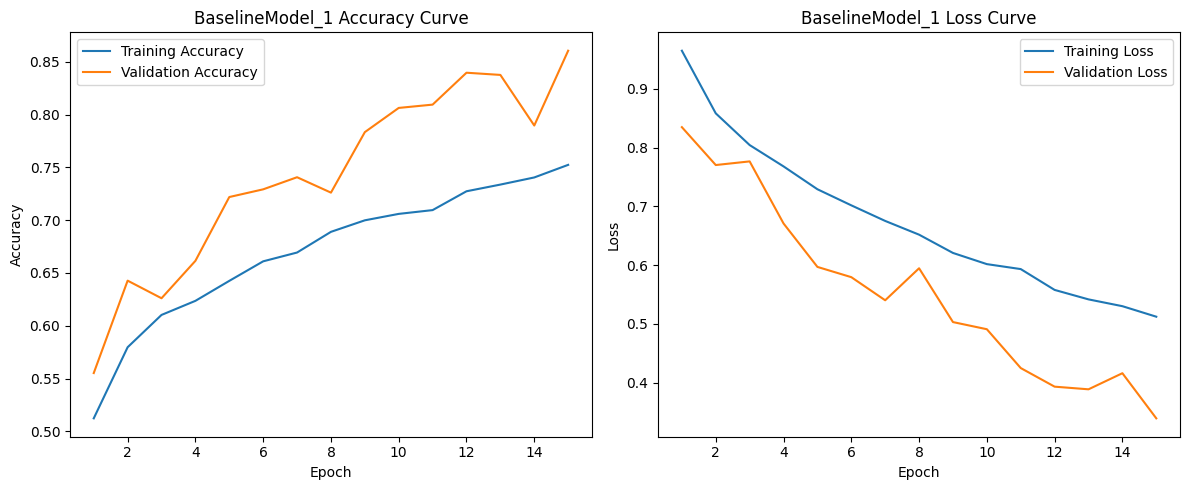

In [23]:
#Step 21
# Plot model learning curves
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accs, label="Training Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.title("BaselineModel_1 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("BaselineModel_1 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
#Step 22
# Load best saved model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Store predictions and true labels
all_preds = []
all_labels = []

# Run prediction on test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute accuracy and macro F1-score
accuracy_cnn1 = accuracy_score(all_labels, all_preds)
f1_cnn1 = f1_score(all_labels, all_preds, average="macro")

print("BaselineModel_1 Test Accuracy:", accuracy_cnn1)
print("BaselineModel_1 Macro F1-score:", f1_cnn1)

BaselineModel_1 Test Accuracy: 0.85
BaselineModel_1 Macro F1-score: 0.8502985607896622


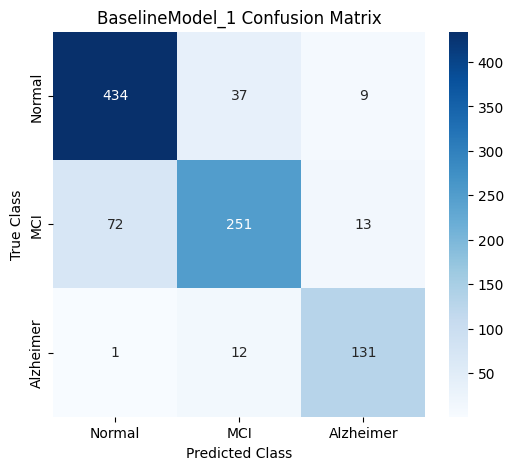

              precision    recall  f1-score   support

      Normal       0.86      0.90      0.88       480
         MCI       0.84      0.75      0.79       336
   Alzheimer       0.86      0.91      0.88       144

    accuracy                           0.85       960
   macro avg       0.85      0.85      0.85       960
weighted avg       0.85      0.85      0.85       960



In [25]:
#Step 23
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("BaselineModel_1 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Show precision, recall and F1-score for each class
print(classification_report(all_labels, all_preds, target_names=class_names))

Define BaselineModel_2

In [26]:
#Step 1
# Define improved custom CNN model
class BaselineCNN2(nn.Module):
    def __init__(self, num_classes=3):
        super(BaselineCNN2, self).__init__()

        # Deeper feature extractor than BaselineModel_1
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Stronger classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create model
model2 = BaselineCNN2(num_classes=3).to(device)

print(model2)

BaselineCNN2(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [27]:
#Step 2
# Define loss and optimizer for BaselineModel_2
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=5e-5)

In [28]:
#Step 3
# Train BaselineModel_2
NUM_EPOCHS_2 = 20

train_losses_2 = []
val_losses_2 = []
train_accs_2 = []
val_accs_2 = []

best_val_acc_2 = 0.0
best_model_path_2 = "baseline_model_2_clean.pth"

for epoch in range(NUM_EPOCHS_2):
    train_loss, train_acc = train_one_epoch(
        model2,
        train_loader,
        criterion2,
        optimizer2,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model2,
        val_loader,
        criterion2,
        device
    )

    train_losses_2.append(train_loss)
    val_losses_2.append(val_loss)
    train_accs_2.append(train_acc)
    val_accs_2.append(val_acc)

    if val_acc > best_val_acc_2:
        best_val_acc_2 = val_acc
        torch.save(model2.state_dict(), best_model_path_2)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_2}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] | Train Loss: 0.9834 | Train Acc: 0.4979 | Val Loss: 0.8456 | Val Acc: 0.5979
Epoch [2/20] | Train Loss: 0.8529 | Train Acc: 0.5898 | Val Loss: 0.8644 | Val Acc: 0.5469
Epoch [3/20] | Train Loss: 0.7805 | Train Acc: 0.6352 | Val Loss: 0.6863 | Val Acc: 0.6917
Epoch [4/20] | Train Loss: 0.7289 | Train Acc: 0.6595 | Val Loss: 0.6334 | Val Acc: 0.7042
Epoch [5/20] | Train Loss: 0.6788 | Train Acc: 0.6913 | Val Loss: 0.6660 | Val Acc: 0.7115
Epoch [6/20] | Train Loss: 0.6297 | Train Acc: 0.7154 | Val Loss: 0.5431 | Val Acc: 0.7292
Epoch [7/20] | Train Loss: 0.5810 | Train Acc: 0.7443 | Val Loss: 0.4575 | Val Acc: 0.7937
Epoch [8/20] | Train Loss: 0.5382 | Train Acc: 0.7669 | Val Loss: 0.4418 | Val Acc: 0.8010
Epoch [9/20] | Train Loss: 0.4859 | Train Acc: 0.7945 | Val Loss: 0.3987 | Val Acc: 0.8125
Epoch [10/20] | Train Loss: 0.4486 | Train Acc: 0.8090 | Val Loss: 0.4190 | Val Acc: 0.8104
Epoch [11/20] | Train Loss: 0.4022 | Train Acc: 0.8293 | Val Loss: 0.2866 | Val Acc: 0.87

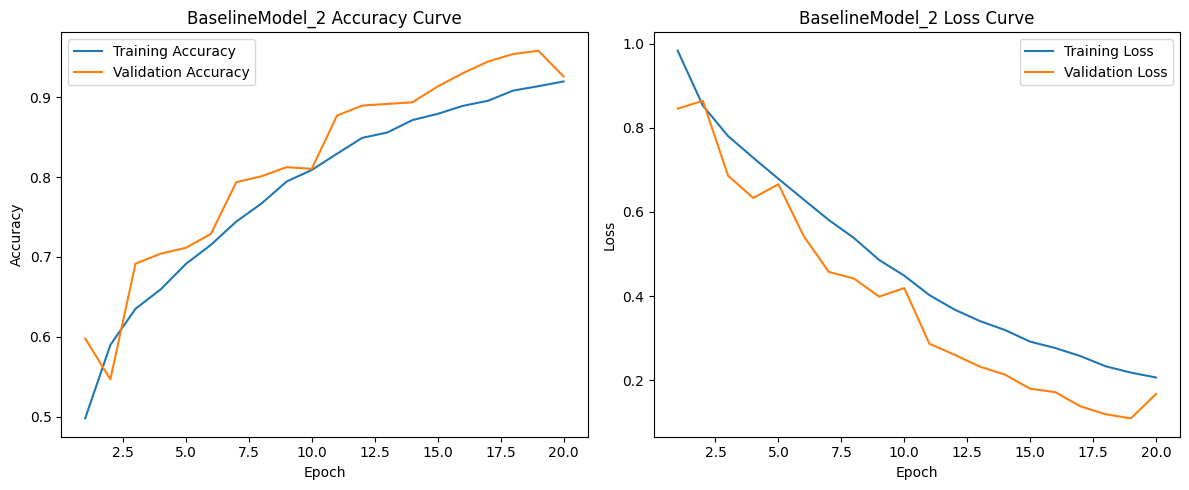

In [29]:
#Step 4
# Plot BaselineModel_2 learning curves
epochs_range_2 = range(1, NUM_EPOCHS_2 + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_2, train_accs_2, label="Training Accuracy")
plt.plot(epochs_range_2, val_accs_2, label="Validation Accuracy")
plt.title("BaselineModel_2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_2, train_losses_2, label="Training Loss")
plt.plot(epochs_range_2, val_losses_2, label="Validation Loss")
plt.title("BaselineModel_2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
#Step 5
# Load best BaselineModel_2
model2.load_state_dict(torch.load(best_model_path_2, map_location=device))
model2.eval()

all_preds_2 = []
all_labels_2 = []

# Predict on test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model2(images)
        _, preds = torch.max(outputs, 1)

        all_preds_2.extend(preds.cpu().numpy())
        all_labels_2.extend(labels.numpy())

# Calculate metrics
accuracy_cnn2 = accuracy_score(all_labels_2, all_preds_2)
f1_cnn2 = f1_score(all_labels_2, all_preds_2, average="macro")

print("BaselineModel_2 Test Accuracy:", accuracy_cnn2)
print("BaselineModel_2 Macro F1-score:", f1_cnn2)

BaselineModel_2 Test Accuracy: 0.9458333333333333
BaselineModel_2 Macro F1-score: 0.953771048641372


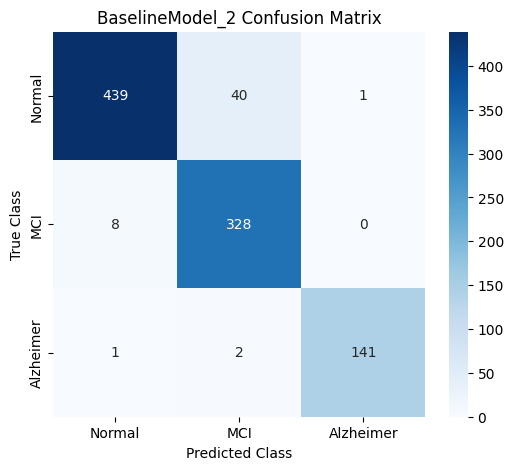

              precision    recall  f1-score   support

      Normal       0.98      0.91      0.95       480
         MCI       0.89      0.98      0.93       336
   Alzheimer       0.99      0.98      0.99       144

    accuracy                           0.95       960
   macro avg       0.95      0.96      0.95       960
weighted avg       0.95      0.95      0.95       960



In [31]:
#Step 6
# Plot confusion matrix for BaselineModel_2
cm2 = confusion_matrix(all_labels_2, all_preds_2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("BaselineModel_2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print(classification_report(all_labels_2, all_preds_2, target_names=class_names))

**PretrainedModel_1: ResNet18.**
**TRANSFORMER**

In [32]:
from torchvision import models

In [33]:
from torchvision import models

In [34]:
#Step 1
# ResNet18 expects 3-channel images, so grayscale MRI images are converted to 3 channels
train_transform_resnet = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation and test images are not augmented
eval_transform_resnet = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [35]:
#Step 2
# Create datasets for ResNet18
train_dataset_resnet = MRIDataset(train_final_df, transform=train_transform_resnet)
val_dataset_resnet = MRIDataset(val_original_df, transform=eval_transform_resnet)
test_dataset_resnet = MRIDataset(test_original_df, transform=eval_transform_resnet)

# Create dataloaders for ResNet18
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=16, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=16, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=16, shuffle=False)

print("ResNet18 training batches:", len(train_loader_resnet))
print("ResNet18 validation batches:", len(val_loader_resnet))
print("ResNet18 test batches:", len(test_loader_resnet))

ResNet18 training batches: 750
ResNet18 validation batches: 60
ResNet18 test batches: 60


In [36]:
#sTEP 3
# Load pretrained ResNet18 model
import torch
import torch.nn as nn
from torchvision import models

num_classes = 3

try:
    # Try pretrained ResNet18
    weights = models.ResNet18_Weights.DEFAULT
    model_resnet = models.resnet18(weights=weights)
    print("Pretrained ResNet18 loaded successfully.")

except Exception as e:
    # If internet/download fails, use ResNet18 without pretrained weights
    print("Could not download pretrained weights.")
    print("Using ResNet18 without pretrained weights instead.")
    model_resnet = models.resnet18(weights=None)

# Replace final layer for your 3 classes
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)

model_resnet = model_resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Pretrained ResNet18 loaded successfully.


In [37]:
#Step 4
# Define loss function and optimizer for ResNet18
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=1e-4)

In [38]:
#Step 5
# Train ResNet18 model
NUM_EPOCHS_RESNET = 10

train_losses_resnet = []
val_losses_resnet = []
train_accs_resnet = []
val_accs_resnet = []

best_val_acc_resnet = 0.0
best_model_path_resnet = "resnet18_best.pth"

for epoch in range(NUM_EPOCHS_RESNET):
    train_loss, train_acc = train_one_epoch(
        model_resnet,
        train_loader_resnet,
        criterion_resnet,
        optimizer_resnet,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model_resnet,
        val_loader_resnet,
        criterion_resnet,
        device
    )

    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accs_resnet.append(train_acc)
    val_accs_resnet.append(val_acc)

    if val_acc > best_val_acc_resnet:
        best_val_acc_resnet = val_acc
        torch.save(model_resnet.state_dict(), best_model_path_resnet)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_RESNET}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 0.5730 | Train Acc: 0.7543 | Val Loss: 0.2723 | Val Acc: 0.8875
Epoch [2/10] | Train Loss: 0.2410 | Train Acc: 0.9087 | Val Loss: 0.0972 | Val Acc: 0.9646
Epoch [3/10] | Train Loss: 0.1262 | Train Acc: 0.9528 | Val Loss: 0.0515 | Val Acc: 0.9802
Epoch [4/10] | Train Loss: 0.0994 | Train Acc: 0.9643 | Val Loss: 0.0537 | Val Acc: 0.9812
Epoch [5/10] | Train Loss: 0.0694 | Train Acc: 0.9764 | Val Loss: 0.0322 | Val Acc: 0.9865
Epoch [6/10] | Train Loss: 0.0589 | Train Acc: 0.9789 | Val Loss: 0.0209 | Val Acc: 0.9969
Epoch [7/10] | Train Loss: 0.0548 | Train Acc: 0.9823 | Val Loss: 0.0551 | Val Acc: 0.9823
Epoch [8/10] | Train Loss: 0.0340 | Train Acc: 0.9888 | Val Loss: 0.0455 | Val Acc: 0.9865
Epoch [9/10] | Train Loss: 0.0395 | Train Acc: 0.9862 | Val Loss: 0.0347 | Val Acc: 0.9875
Epoch [10/10] | Train Loss: 0.0489 | Train Acc: 0.9825 | Val Loss: 0.0279 | Val Acc: 0.9896


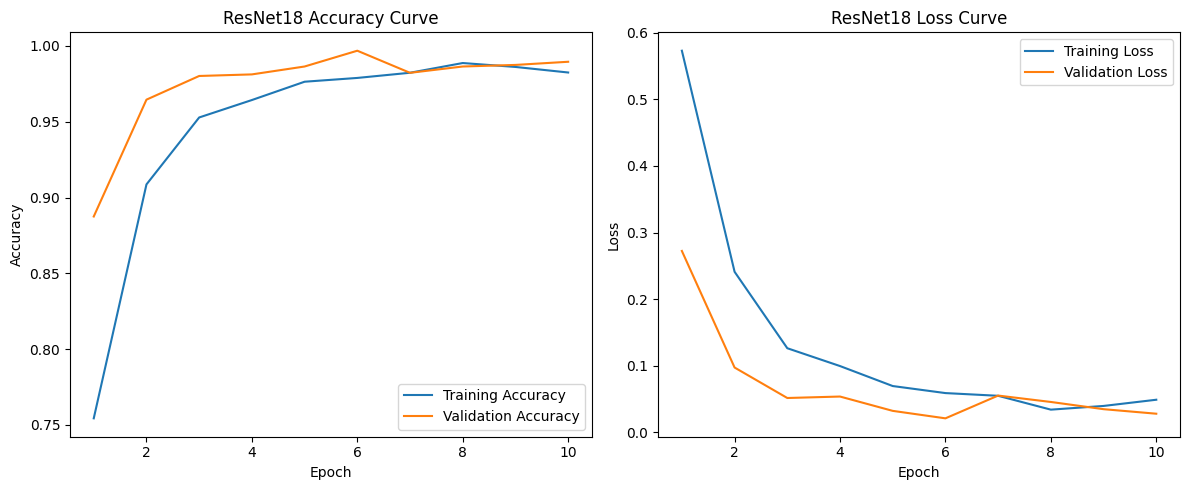

In [39]:
#Step 6
# Plot ResNet18 training and validation curves
epochs_range_resnet = range(1, NUM_EPOCHS_RESNET + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet, train_accs_resnet, label="Training Accuracy")
plt.plot(epochs_range_resnet, val_accs_resnet, label="Validation Accuracy")
plt.title("ResNet18 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet, train_losses_resnet, label="Training Loss")
plt.plot(epochs_range_resnet, val_losses_resnet, label="Validation Loss")
plt.title("ResNet18 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
#Step 7
# Load best ResNet18 model
model_resnet.load_state_dict(torch.load(best_model_path_resnet, map_location=device))
model_resnet.eval()

all_preds_resnet = []
all_labels_resnet = []

# Predict on test set
with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)

        outputs = model_resnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds_resnet.extend(preds.cpu().numpy())
        all_labels_resnet.extend(labels.numpy())

# Calculate metrics
accuracy_resnet = accuracy_score(all_labels_resnet, all_preds_resnet)
f1_resnet = f1_score(all_labels_resnet, all_preds_resnet, average="macro")

print("ResNet18 Test Accuracy:", accuracy_resnet)
print("ResNet18 Macro F1-score:", f1_resnet)

ResNet18 Test Accuracy: 0.9958333333333333
ResNet18 Macro F1-score: 0.9941712571932141


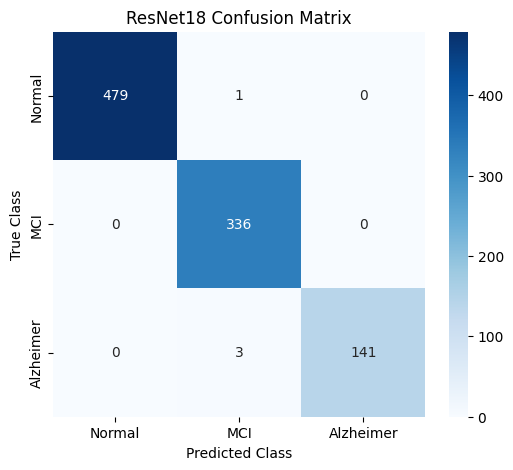

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       480
         MCI       0.99      1.00      0.99       336
   Alzheimer       1.00      0.98      0.99       144

    accuracy                           1.00       960
   macro avg       1.00      0.99      0.99       960
weighted avg       1.00      1.00      1.00       960



In [41]:
#Step 8
# Plot confusion matrix for ResNet18
cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print(classification_report(all_labels_resnet, all_preds_resnet, target_names=class_names))

EfficientNe- BO

In [42]:
#Step 1
# Load EfficientNet-B0 model
try:
    weights_eff = models.EfficientNet_B0_Weights.DEFAULT
    model_effnet = models.efficientnet_b0(weights=weights_eff)
except:
    model_effnet = models.efficientnet_b0(weights=None)

# Replace final classifier layer for 3 classes
model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, 3)

# Move model to GPU/CPU
model_effnet = model_effnet.to(device)

print("EfficientNet-B0 model ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 


EfficientNet-B0 model ready.


In [43]:
#Step 2
train_loader_resnet
val_loader_resnet
test_loader_resnet

In [44]:
#Step 3
criterion_effnet = nn.CrossEntropyLoss()
optimizer_effnet = optim.Adam(model_effnet.parameters(), lr=1e-4)

NUM_EPOCHS_EFFNET = 10

train_losses_effnet = []
val_losses_effnet = []
train_accs_effnet = []
val_accs_effnet = []

best_val_acc_effnet = 0.0
best_model_path_effnet = "efficientnet_b0_best.pth"

for epoch in range(NUM_EPOCHS_EFFNET):
    train_loss, train_acc = train_one_epoch(
        model_effnet,
        train_loader_resnet,
        criterion_effnet,
        optimizer_effnet,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model_effnet,
        val_loader_resnet,
        criterion_effnet,
        device
    )

    train_losses_effnet.append(train_loss)
    val_losses_effnet.append(val_loss)
    train_accs_effnet.append(train_acc)
    val_accs_effnet.append(val_acc)

    if val_acc > best_val_acc_effnet:
        best_val_acc_effnet = val_acc
        torch.save(model_effnet.state_dict(), best_model_path_effnet)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS_EFFNET}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 0.7087 | Train Acc: 0.6787 | Val Loss: 0.4424 | Val Acc: 0.8187
Epoch [2/10] | Train Loss: 0.4075 | Train Acc: 0.8357 | Val Loss: 0.1895 | Val Acc: 0.9260
Epoch [3/10] | Train Loss: 0.2355 | Train Acc: 0.9087 | Val Loss: 0.0944 | Val Acc: 0.9688
Epoch [4/10] | Train Loss: 0.1519 | Train Acc: 0.9428 | Val Loss: 0.0564 | Val Acc: 0.9792
Epoch [5/10] | Train Loss: 0.1089 | Train Acc: 0.9602 | Val Loss: 0.1223 | Val Acc: 0.9542
Epoch [6/10] | Train Loss: 0.0881 | Train Acc: 0.9681 | Val Loss: 0.0311 | Val Acc: 0.9906
Epoch [7/10] | Train Loss: 0.0692 | Train Acc: 0.9759 | Val Loss: 0.0386 | Val Acc: 0.9833
Epoch [8/10] | Train Loss: 0.0536 | Train Acc: 0.9818 | Val Loss: 0.0185 | Val Acc: 0.9948
Epoch [9/10] | Train Loss: 0.0504 | Train Acc: 0.9831 | Val Loss: 0.0070 | Val Acc: 0.9979
Epoch [10/10] | Train Loss: 0.0519 | Train Acc: 0.9821 | Val Loss: 0.0111 | Val Acc: 0.9979


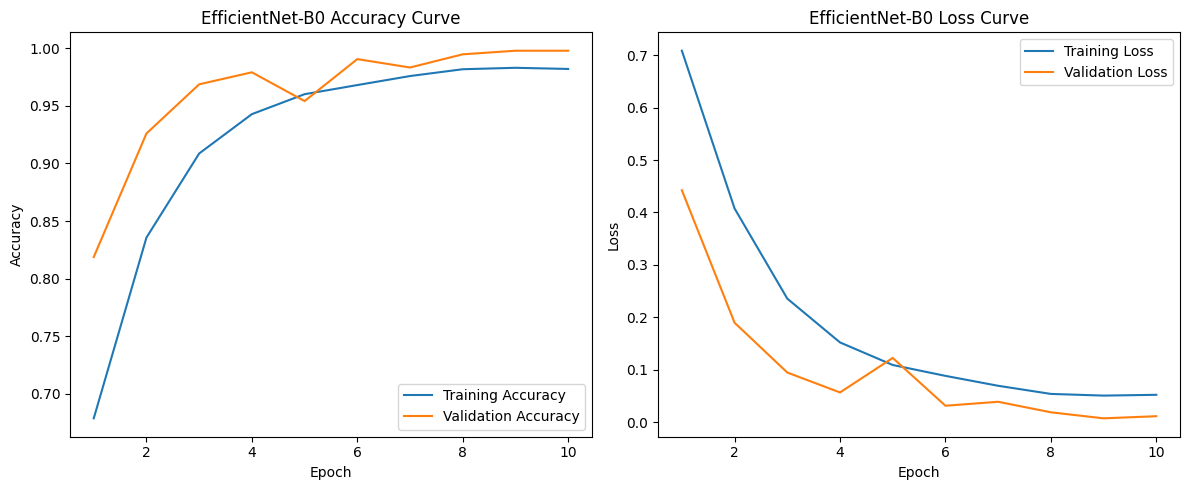

In [45]:
#Step 4
epochs_range_effnet = range(1, NUM_EPOCHS_EFFNET + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_effnet, train_accs_effnet, label="Training Accuracy")
plt.plot(epochs_range_effnet, val_accs_effnet, label="Validation Accuracy")
plt.title("EfficientNet-B0 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_effnet, train_losses_effnet, label="Training Loss")
plt.plot(epochs_range_effnet, val_losses_effnet, label="Validation Loss")
plt.title("EfficientNet-B0 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
#Step 5
model_effnet.load_state_dict(torch.load(best_model_path_effnet, map_location=device))
model_effnet.eval()

all_preds_effnet = []
all_labels_effnet = []

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)

        outputs = model_effnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds_effnet.extend(preds.cpu().numpy())
        all_labels_effnet.extend(labels.numpy())

accuracy_effnet = accuracy_score(all_labels_effnet, all_preds_effnet)
f1_effnet = f1_score(all_labels_effnet, all_preds_effnet, average="macro")

print("EfficientNet-B0 Test Accuracy:", accuracy_effnet)
print("EfficientNet-B0 Macro F1-score:", f1_effnet)

EfficientNet-B0 Test Accuracy: 0.9979166666666667
EfficientNet-B0 Macro F1-score: 0.9983134920634921


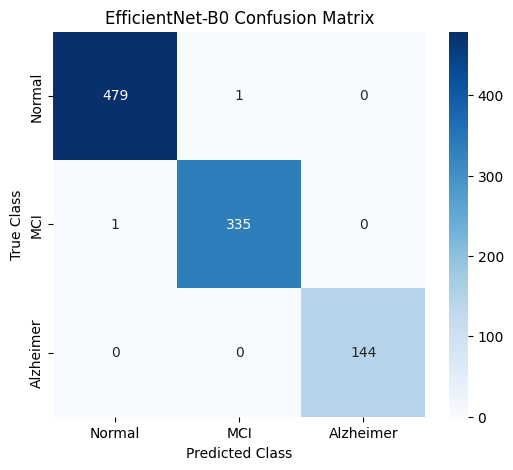

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       480
         MCI       1.00      1.00      1.00       336
   Alzheimer       1.00      1.00      1.00       144

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [47]:
#Step 6
cm_effnet = confusion_matrix(all_labels_effnet, all_preds_effnet)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_effnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print(classification_report(all_labels_effnet, all_preds_effnet, target_names=class_names))

GRAD-CAM Implementation

In [48]:
# Install Grad-CAM library
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=a3168f7aa004dbcafaa4b047b4368f1c8147932a12ec0b21eba0759d41936a1c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [49]:
# Import Grad-CAM tools
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import cv2                                               

In [50]:
#Step 3 — Select target layer for EfficientNet-B0
# Select the last convolutional block of EfficientNet-B0
target_layers = [model_effnet.features[-1]]

In [51]:
#Step 4 — Function to prepare one image
# Prepare image for Grad-CAM visualization
def prepare_image_for_gradcam(image_path):
    original_img = Image.open(image_path).convert("RGB")
    original_img = original_img.resize((224, 224))

    rgb_img = np.array(original_img).astype(np.float32) / 255.0

    input_tensor = eval_transform_resnet(Image.open(image_path).convert("L"))
    input_tensor = input_tensor.unsqueeze(0).to(device)

    return rgb_img, input_tensor

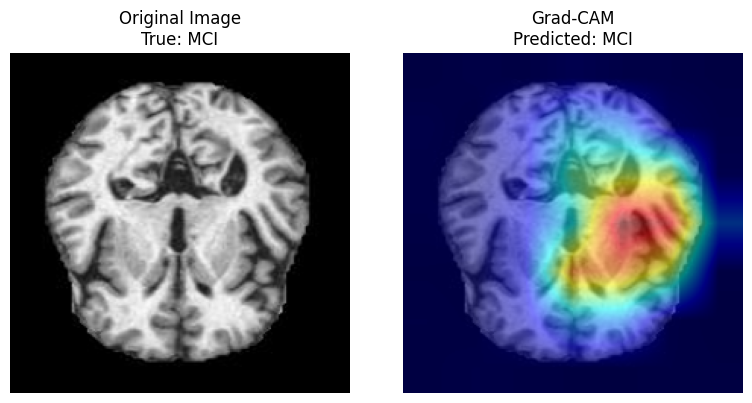

In [52]:
#Step 5 — Generate Grad-CAM for one image
# Generate Grad-CAM for a selected test image
image_path = test_original_df.iloc[0]["filepath"]
true_label = test_original_df.iloc[0]["label"]

rgb_img, input_tensor = prepare_image_for_gradcam(image_path)

model_effnet.eval()

with torch.no_grad():
    output = model_effnet(input_tensor)
    predicted_class = output.argmax(dim=1).item()

cam = GradCAM(
    model=model_effnet,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(predicted_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0, :]

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original Image\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM\nPredicted: {class_names[predicted_class]}")
plt.axis("off")

plt.tight_layout()
plt.show()

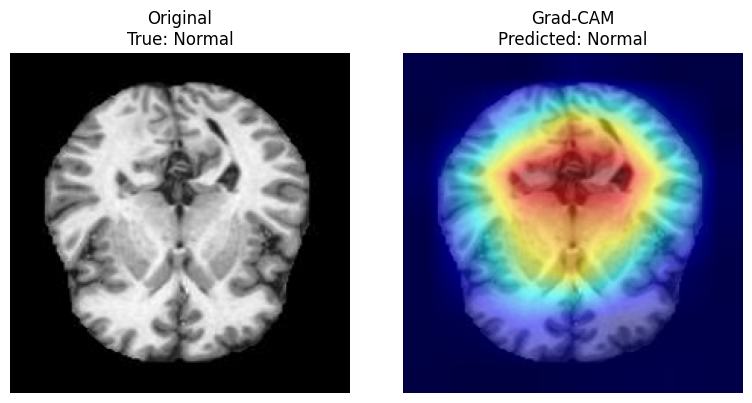

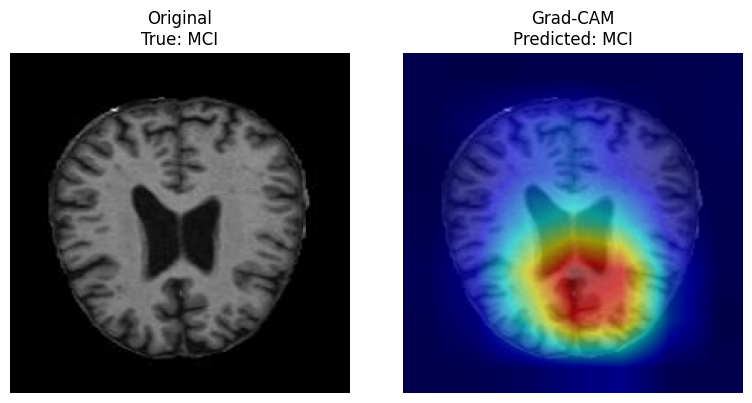

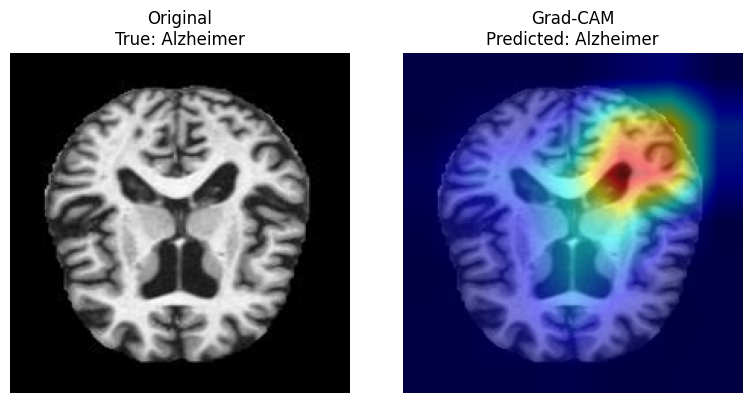

In [53]:
#Step 6 — Grad-CAM for one image per class
# Generate Grad-CAM for one sample from each class
for cls in class_names:
    sample_row = test_original_df[test_original_df["label"] == cls].sample(1, random_state=SEED).iloc[0]
    image_path = sample_row["filepath"]
    true_label = sample_row["label"]

    rgb_img, input_tensor = prepare_image_for_gradcam(image_path)

    model_effnet.eval()

    with torch.no_grad():
        output = model_effnet(input_tensor)
        predicted_class = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(predicted_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0, :]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM\nPredicted: {class_names[predicted_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [54]:
# Create comparison table for all models
comparison_df = pd.DataFrame({
    "Model": [
        "BaselineModel_1",
        "BaselineModel_2",
        "ResNet18",
        "EfficientNet-B0"
    ],
    "Accuracy": [
        accuracy_cnn1,
        accuracy_cnn2,
        accuracy_resnet,
        accuracy_effnet
    ],
    "Macro F1-score": [
        f1_cnn1,
        f1_cnn2,
        f1_resnet,
        f1_effnet
    ]
})

# Display comparison table
comparison_df

,Model,Accuracy,Macro F1-score
0,BaselineModel_1,0.850000,0.850299
1,BaselineModel_2,0.945833,0.953771
2,ResNet18,0.995833,0.994171
3,EfficientNet-B0,0.997917,0.998313


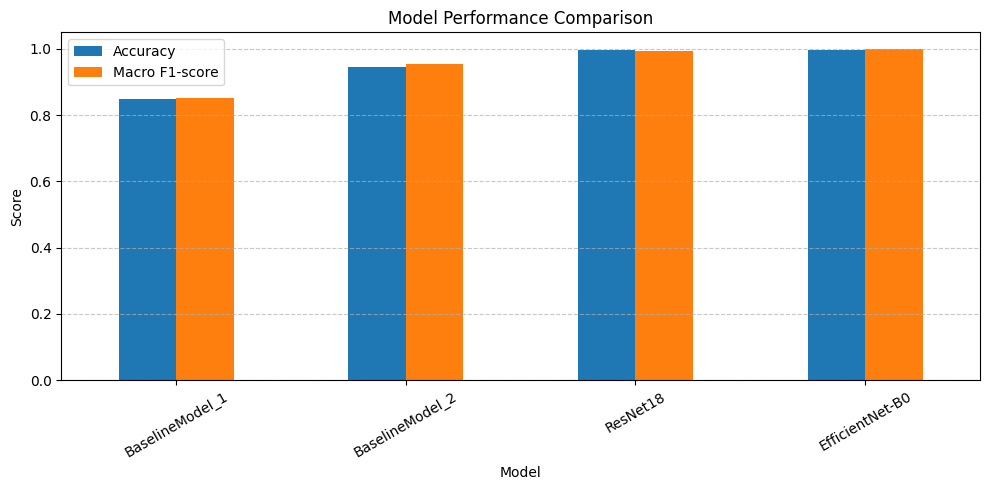

In [55]:
# Plot accuracy and F1-score comparison
comparison_df.set_index("Model")[["Accuracy", "Macro F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

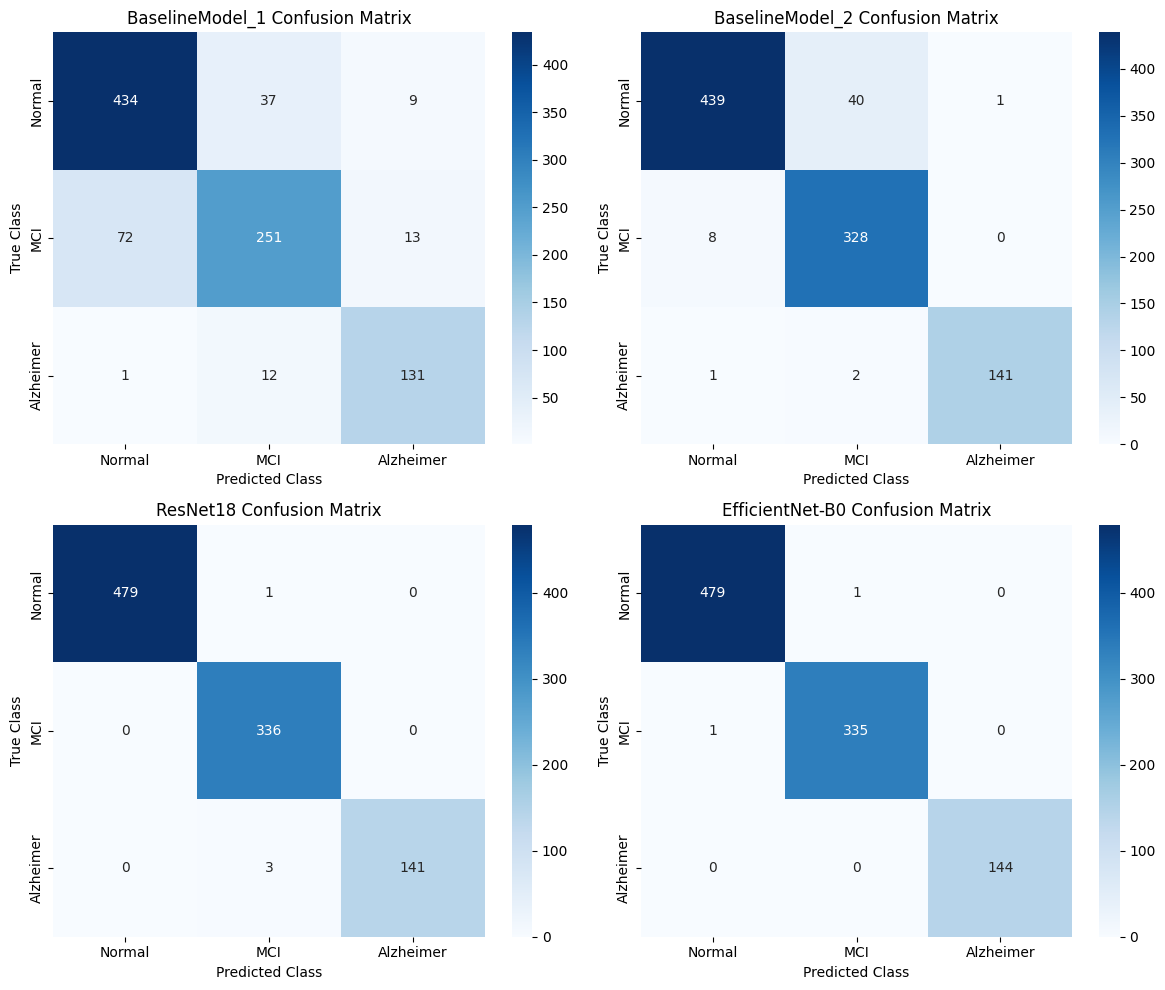

In [56]:
# Store confusion matrices
confusion_matrices = {
    "BaselineModel_1": confusion_matrix(all_labels, all_preds),
    "BaselineModel_2": confusion_matrix(all_labels_2, all_preds_2),
    "ResNet18": confusion_matrix(all_labels_resnet, all_preds_resnet),
    "EfficientNet-B0": confusion_matrix(all_labels_effnet, all_preds_effnet)
}

# Plot confusion matrices side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

plt.tight_layout()
plt.show()

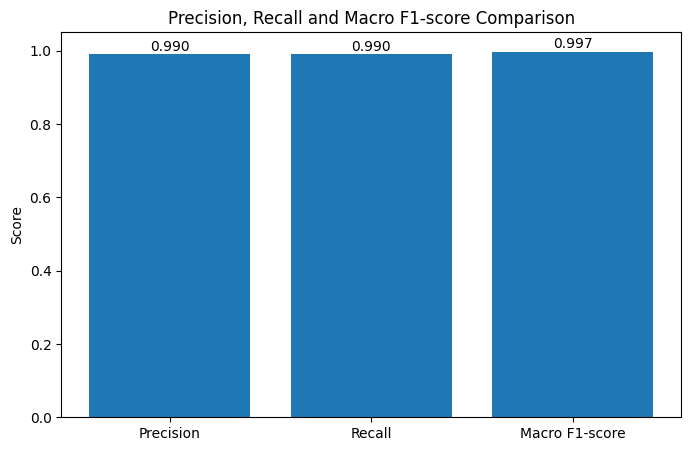

In [57]:
# Precision, Recall and F1-score Comparison Chart

import matplotlib.pyplot as plt

# Metrics and values
metrics = ['Precision', 'Recall', 'Macro F1-score']
values = [0.99, 0.99, 0.997]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values)

# Labels and title
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Precision, Recall and Macro F1-score Comparison')

# Add values on top of bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f'{value:.3f}',
        ha='center'
    )

# Save figure
plt.savefig('evaluation_metrics_chart.png', dpi=300, bbox_inches='tight')

# Show chart
plt.show()

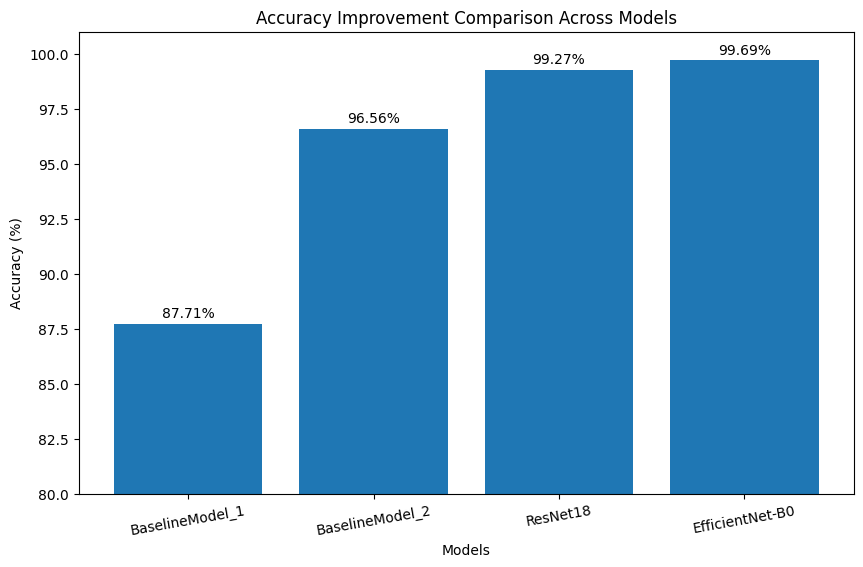

In [58]:
# Accuracy Improvement Comparison Across Models

import matplotlib.pyplot as plt

# Model names
models = [
    'BaselineModel_1',
    'BaselineModel_2',
    'ResNet18',
    'EfficientNet-B0'
]

# Accuracy values
accuracies = [87.71, 96.56, 99.27, 99.69]

# Create figure
plt.figure(figsize=(10,6))

# Create bar chart
bars = plt.bar(models, accuracies)

# Labels and title
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.ylim(80, 101)
plt.title('Accuracy Improvement Comparison Across Models')

# Add accuracy labels on top
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        accuracy + 0.3,
        f'{accuracy:.2f}%',
        ha='center'
    )

# Rotate x-axis labels slightly
plt.xticks(rotation=10)

# Save figure
plt.savefig(
    'accuracy_comparison_chart.png',
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()